1.- Selecciona un activo financiero y descarga precios históricos de al menos 3 años.

In [48]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

In [49]:
ticker = "AAPL"          
start = "2021-01-01"   
end = "2026-03-01"

In [50]:
initial_capital = 5000
weekly_contribution = 100
n_contributions = initial_capital // weekly_contribution

In [51]:
trading_days_per_year = 252
days_per_week = 5       
T_days = int(n_contributions * days_per_week)

In [52]:
n_sims = 10000

In [53]:
prices = yf.download(ticker, start=start, end=end)['Close']

[*********************100%***********************]  1 of 1 completed


In [54]:
rets = prices.pct_change().dropna()
mu_daily = float(rets.mean().iloc[0])
sigma_daily = float(rets.std().iloc[0])          
S0 = float(prices.iloc[-1])

C:\Users\Nicolas\AppData\Local\Temp\ipykernel_1720\2855303165.py:4: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  S0 = float(prices.iloc[-1])


2.- Simula 10,000 trayectorias de precios futuros usando Monte Carlo

In [55]:
# GBM: S_{t+1} = S_t * exp((mu - 0.5*sigma^2)dt + sigma*sqrt(dt)*Z)
dt = 1  
Z = np.random.normal(0, 1, size=(n_sims, T_days))
drift = (mu_daily - 0.5 * sigma_daily**2) * dt
diffusion = sigma_daily * np.sqrt(dt) * Z

In [56]:
# Trayectorias de precio
log_returns = drift + diffusion
S_paths = S0 * np.exp(np.cumsum(log_returns, axis=1)) 

3.- Define dos estrategias de inversión con un monto total de $5,000:

- Inversión única: se invierte todo el monto al inicio del periodo.

- Inversión periódica (DCA): se invierten 100 cada semana hasta completar $5,000

In [57]:
# Inversión única al inicio
shares_lump = initial_capital / S0           
final_values_lump = shares_lump * S_paths[:, -1] # valor final

In [58]:
# DCA: $100 cada semana (cada 5 días hábiles)
buy_days = np.arange(1, T_days + 1, days_per_week)  
buy_cols = buy_days - 1                            
buy_cols = buy_cols[:int(n_contributions)] # Se aseguran exactamente 50 aportaciones
shares_dca = np.sum(weekly_contribution / S_paths[:, buy_cols], axis=1) # Acciones compradas por simulación
final_values_dca = shares_dca * S_paths[:, -1] 

4.- Calcula y compara para ambas estrategias:

- Valor final promedio de la inversión.

- Desviación estándar del valor final.

- Probabilidad de que el valor final sea menor al capital invertido.

In [59]:
def resumen(valores, nombre):
    mean_val = np.mean(valores)
    std_val = np.std(valores, ddof=1)
    prob_loss = np.mean(valores < initial_capital) 
    return pd.Series({
        "Estrategia": nombre,
        "Valor final promedio": mean_val,
        "Desv. estándar valor final": std_val,
        "Prob. pérdida (VF < 5000)": prob_loss
    })

summary = pd.DataFrame([
    resumen(final_values_lump, "Inversión única"),
    resumen(final_values_dca, "Inversión periódica (DCA $100/semana)")
])

print("\n=== Resumen Comparativo ===")
print(summary)



=== Resumen Comparativo ===
                              Estrategia  Valor final promedio  \
0                        Inversión única           5998.696262   
1  Inversión periódica (DCA $100/semana)           5486.309865   

   Desv. estándar valor final  Prob. pérdida (VF < 5000)  
0                 1705.393148                     0.3011  
1                  914.345008                     0.3194  


5.- Construye gráficos:

- Histogramas comparativos de los valores finales.

- Evolución promedio de la inversión bajo ambas estrategias.

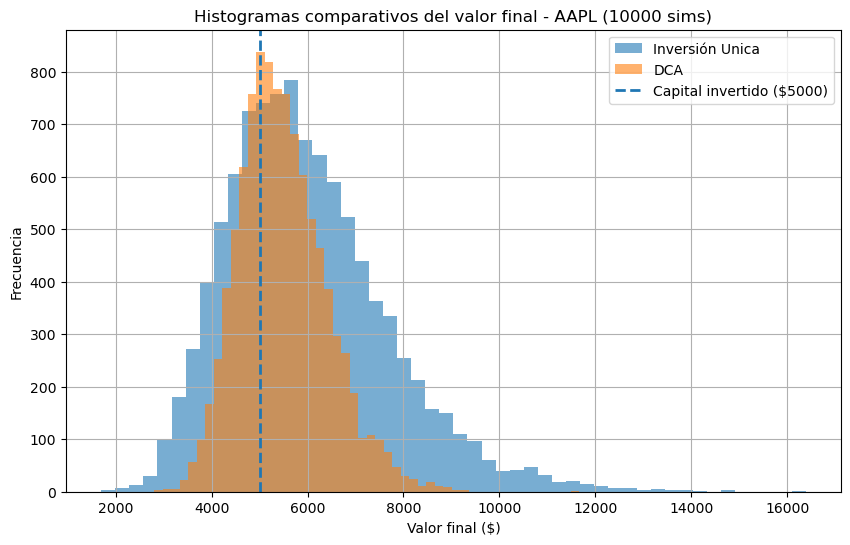

In [60]:
plt.figure(figsize=(10, 6))
plt.hist(final_values_lump, bins=50, alpha=0.6, label="Inversión Unica")
plt.hist(final_values_dca, bins=50, alpha=0.6, label="DCA")
plt.axvline(initial_capital, linestyle="--", linewidth=2, label="Capital invertido ($5000)")
plt.title(f"Histogramas comparativos del valor final - {ticker} ({n_sims} sims)")
plt.xlabel("Valor final ($)")
plt.ylabel("Frecuencia")
plt.legend()
plt.grid(True)
plt.show()

In [61]:
lump_values_over_time = shares_lump * S_paths

In [64]:
# DCA: acumulación de acciones a través del tiempo
shares_acc = np.zeros((n_sims, T_days))
is_buy_day = np.zeros(T_days, dtype=bool)
is_buy_day[buy_cols] = True

for t in range(T_days):
    if t == 0:
        prev = 0.0
    else:
        prev = shares_acc[:, t-1]

    if is_buy_day[t]:
        shares_acc[:, t] = prev + weekly_contribution / S_paths[:, t]
    else:
        shares_acc[:, t] = prev

dca_values_over_time = shares_acc * S_paths

mean_lump_path = lump_values_over_time.mean(axis=0)
mean_dca_path = dca_values_over_time.mean(axis=0)

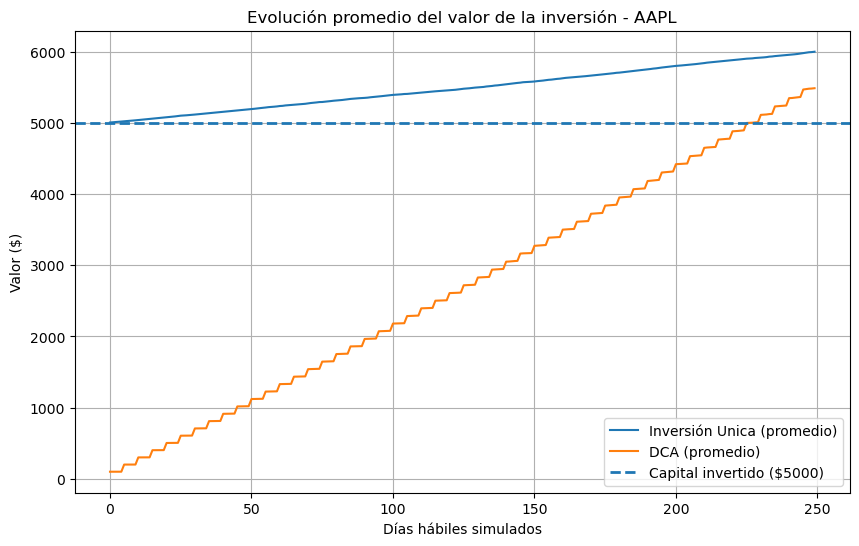

In [65]:
plt.figure(figsize=(10, 6))
plt.plot(mean_lump_path, label="Inversión Unica (promedio)")
plt.plot(mean_dca_path, label="DCA (promedio)")
plt.axhline(initial_capital, linestyle="--", linewidth=2, label="Capital invertido ($5000)")
plt.title(f"Evolución promedio del valor de la inversión - {ticker}")
plt.xlabel("Días hábiles simulados")
plt.ylabel("Valor ($)")
plt.legend()
plt.grid(True)
plt.show()

## Análisis

A partir de las 10,000 simulaciones realizadas para AAPL, se observa que la inversión única presenta un valor final promedio mayor (5,998) en comparación con la estrategia de inversión periódica (5,486). Esto indica que, en promedio, invertir todo el capital desde el inicio permite aprovechar mejor el crecimiento esperado del activo cuando la tendencia es positiva. Sin embargo, la inversión única también presenta una mayor desviación estándar (1,705) frente al DCA (914), lo que implica mayor volatilidad y mayor dispersión de resultados posibles. Aunque la probabilidad de pérdida es ligeramente menor en la inversión única (30.11% vs. 31.94%), el DCA reduce significativamente la variabilidad de los resultados, haciendo que los valores finales estén más concentrados alrededor del promedio.

La inversión periódica resulta más ventajosa en condiciones de alta volatilidad o incertidumbre, ya que reduce el riesgo asociado a entrar al mercado en un momento desfavorable. Al distribuir las aportaciones en el tiempo, el inversionista promedia su precio de compra y disminuye el impacto de fluctuaciones fuertes en el corto plazo. Esta estrategia es especialmente adecuada para perfiles conservadores o para entornos donde no es clara la dirección futura del mercado, ya que ofrece mayor estabilidad en los resultados aunque el rendimiento promedio sea ligeramente menor. Por otro lado, la inversión en un solo momento es preferible cuando se anticipa una tendencia alcista sostenida y el inversionista cuenta con una mayor tolerancia al riesgo. En mercados con crecimiento consistente, colocar todo el capital desde el inicio maximiza el tiempo de exposición y, por ende, el rendimiento esperado. En conclusión, la elección entre ambas estrategias depende del contexto del mercado y del perfil del inversionista, escenarios de crecimiento estable favorecen la inversión única, mientras que entornos volátiles o inciertos hacen más atractiva la estrategia de inversión periódica.